Add project root to python path

In [5]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

sys.path.append(str(PROJECT_ROOT))

print(PROJECT_ROOT)

/home/forge-xii/projects/A3-ENDS


Import Libraries

In [6]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score
)

Load Arrays

In [7]:
X_test = np.load(
    "../datasets/features/CICIDS2017/X_test.npy"
)

y_test = np.load(
    "../datasets/features/CICIDS2017/y_test.npy"
)

# check the shape of the full cleaned dataset
cleaned_df = pd.read_csv("../datasets/processed/CICIDS2017/cleaned_cicids2017.csv")

print(cleaned_df.shape)
print(X_test.shape)
print(y_test.shape)

(2520798, 79)
(504160, 70)
(504160,)


Load Model

In [4]:
model = joblib.load(
    "../models/lightgbm/lightgbm_model.pkl"
)

print("Model loaded successfully")

Model loaded successfully


Predict

In [5]:
y_pred = model.predict(X_test)

/home/forge-xii/projects/A3-ENDS/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Accuracy

In [6]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.9612


Classification report

In [7]:
report = classification_report(
    y_test,
    y_pred,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

report_df

/home/forge-xii/projects/A3-ENDS/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/forge-xii/projects/A3-ENDS/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/forge-xii/projects/A3-ENDS/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"

,precision,recall,f1-score,support
0,0.983717,0.983604,0.983661,419012.000000
1,0.000000,0.000000,0.000000,390.000000
2,0.935431,0.854431,0.893098,25603.000000
3,0.845687,0.338357,0.483333,2057.000000
4,0.917211,0.906014,0.911578,34569.000000
5,0.250248,0.724665,0.372025,1046.000000
6,0.033639,0.020427,0.025419,1077.000000
7,0.368540,0.685497,0.479363,1186.000000
8,0.000000,0.000000,0.000000,2.000000
9,0.000000,0.000000,0.000000,7.000000


Report

In [8]:
report_df.to_csv(
    "../reports/lightgbm_classification_report.csv"
)

print("Classification report saved successfully")

Classification report saved successfully


Confusion Matrix

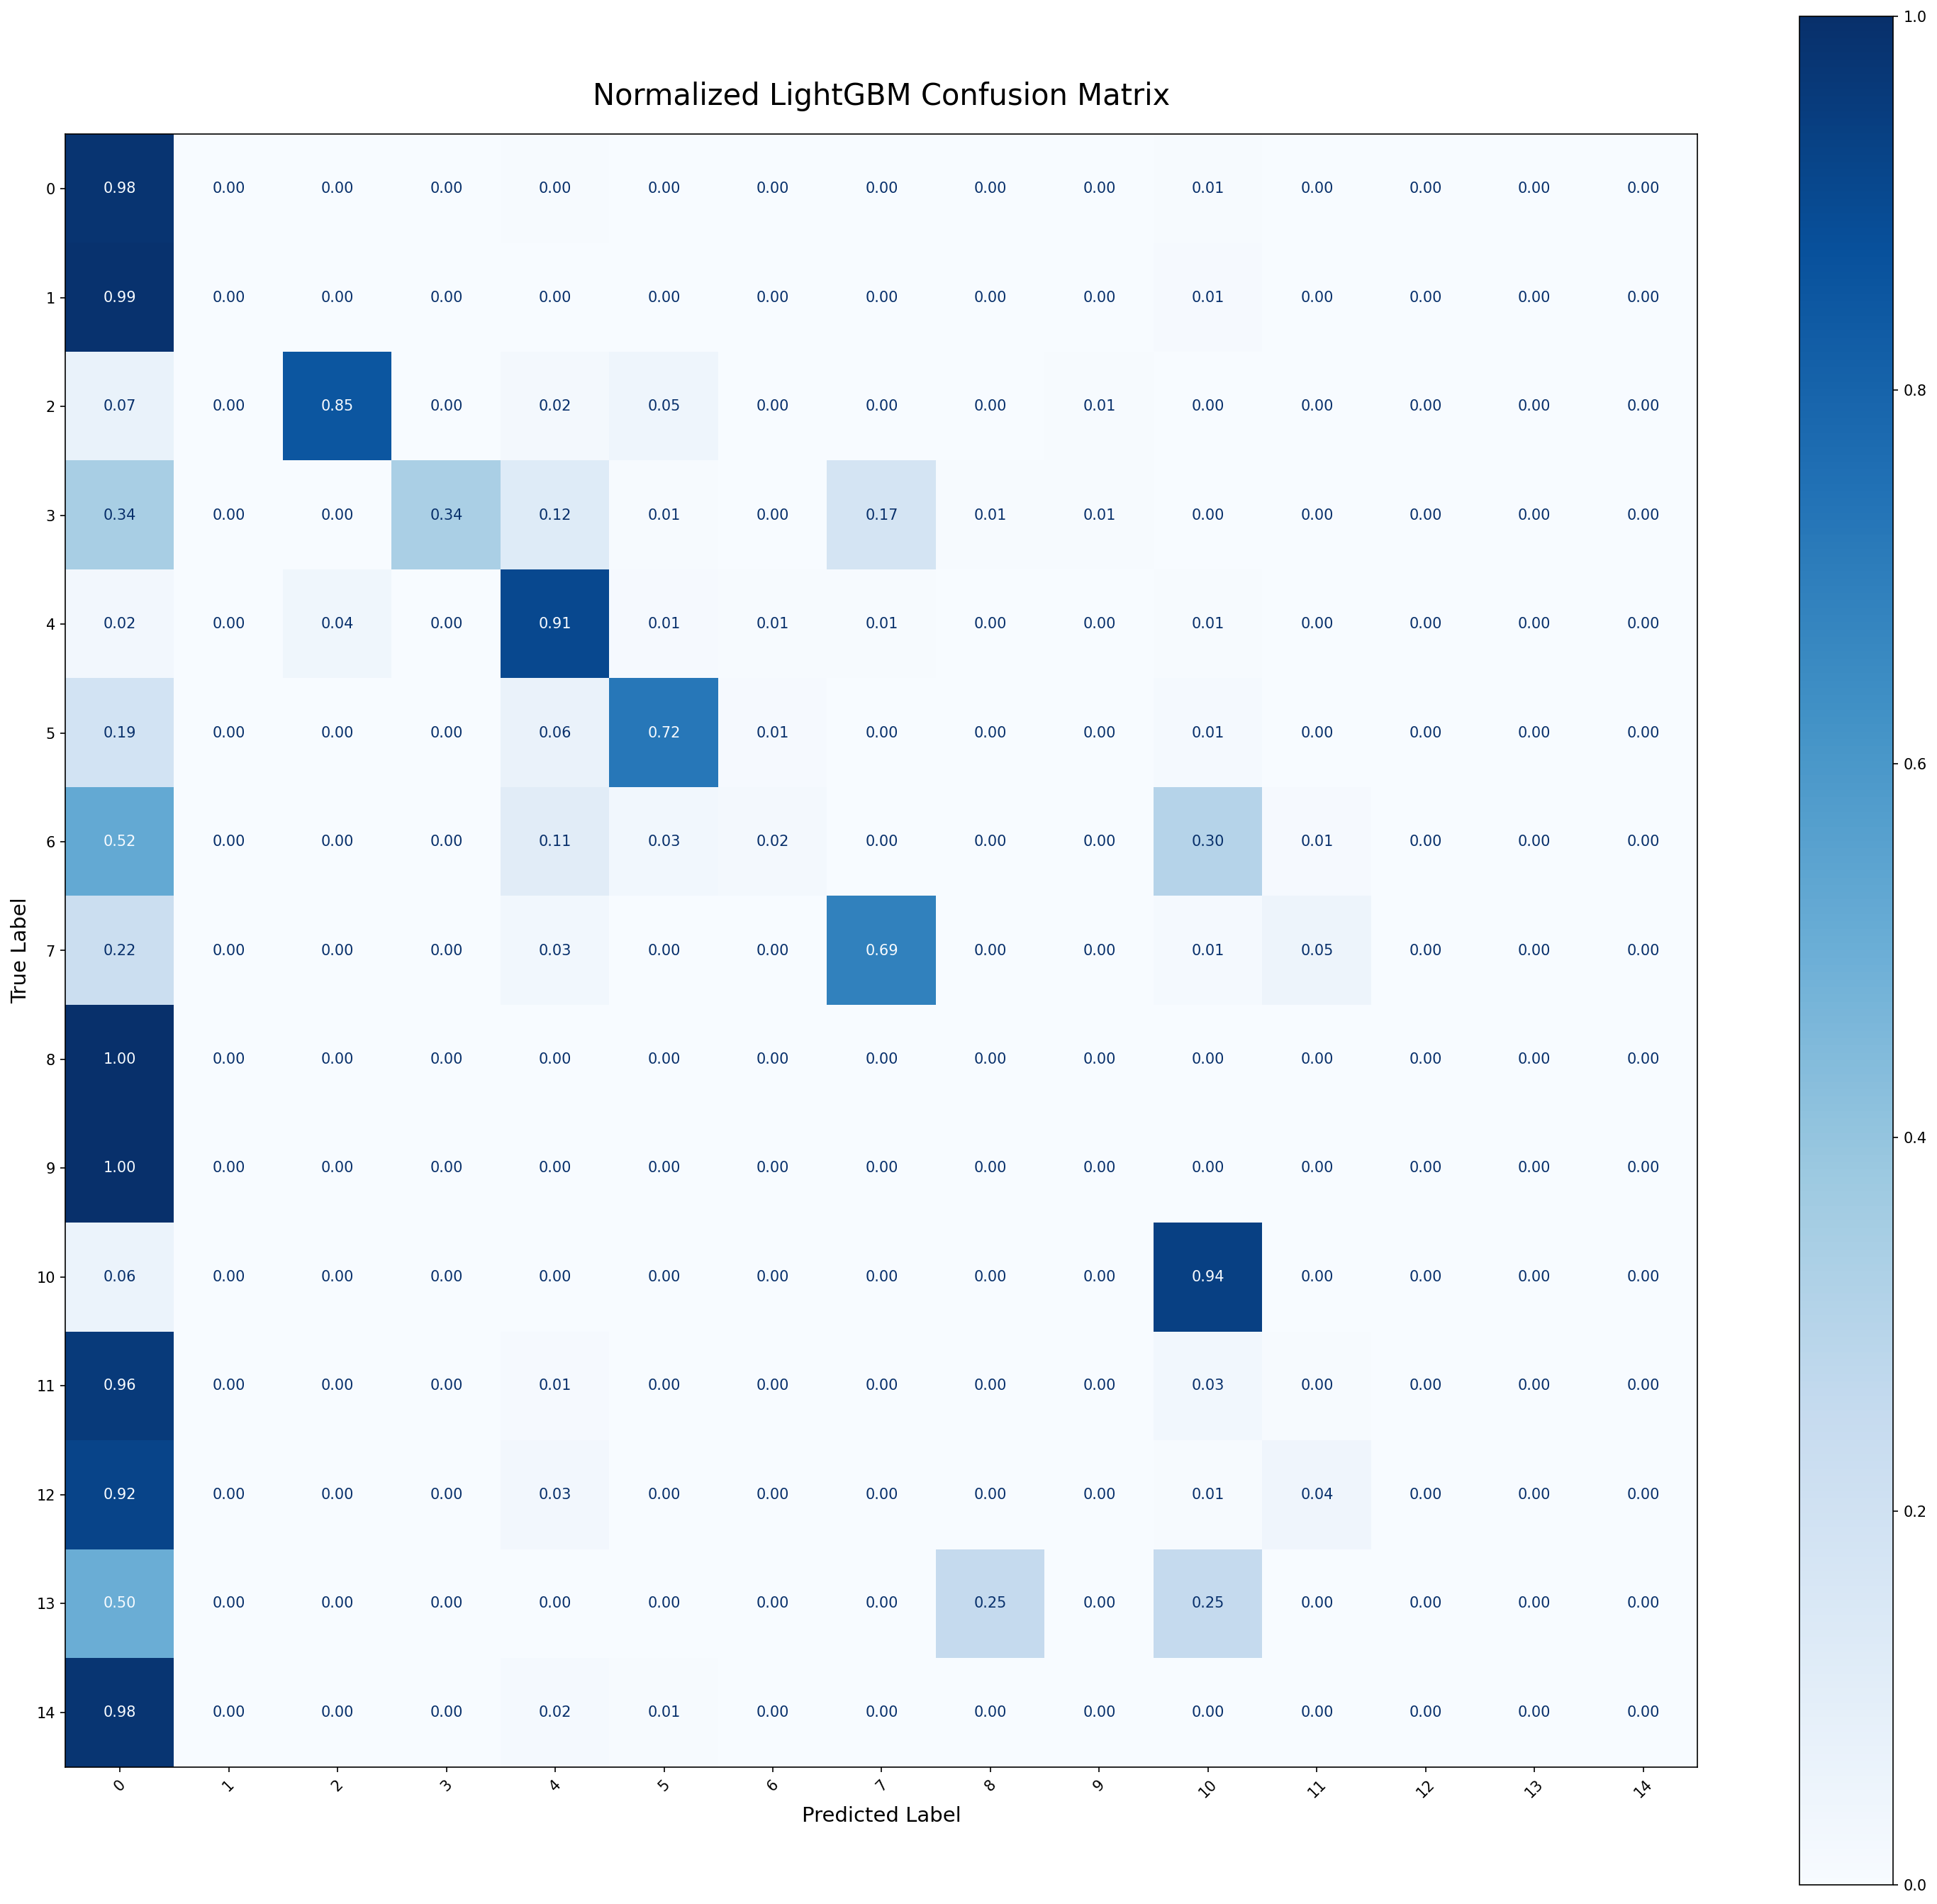

In [9]:
cm = confusion_matrix(
    y_test,
    y_pred,
    normalize='true'
)

fig, ax = plt.subplots(
    figsize=(20, 18),
    dpi=150
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot(
    cmap="Blues",
    xticks_rotation=45,
    ax=ax,
    values_format='.2f'
)

plt.title(
    "Normalized LightGBM Confusion Matrix",
    fontsize=20,
    pad=20
)

plt.xlabel(
    "Predicted Label",
    fontsize=14
)

plt.ylabel(
    "True Label",
    fontsize=14
)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()

plt.show()

Load Features Names

In [10]:
feature_names = joblib.load(
    "../models/selected_features.pkl"
)

Feature Importance Table

In [11]:
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(20)

,Feature,Importance
19,Flow IAT Min,1342
24,Fwd IAT Min,1254
0,Destination Port,1064
29,Bwd IAT Min,1046
59,Init_Win_bytes_backward,790
14,Flow Bytes/s,681
58,Init_Win_bytes_forward,665
1,Flow Duration,649
35,Bwd Packets/s,558
32,Fwd Header Length,555


Feature Importance Visualization

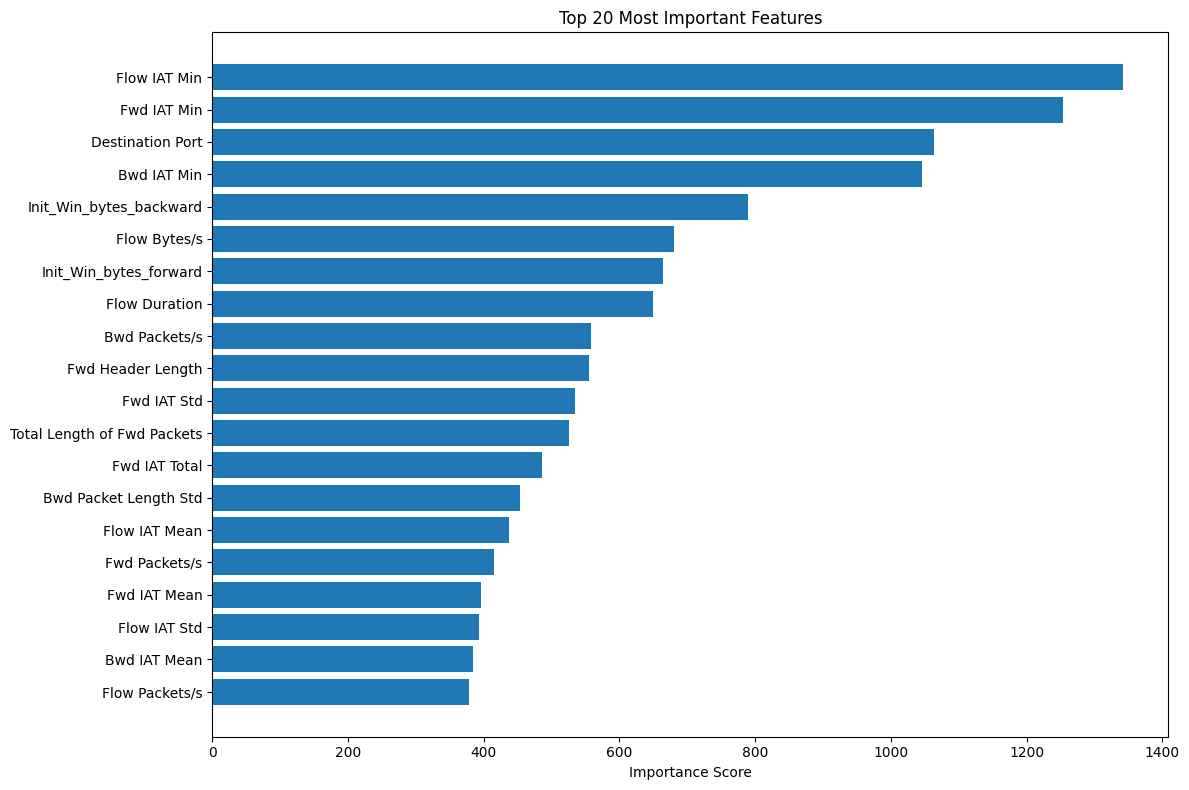

In [12]:
top_features = feature_importance.head(20)

plt.figure(figsize=(12, 8))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Top 20 Most Important Features")

plt.xlabel("Importance Score")

plt.tight_layout()

plt.show()

Save Feature Importance

In [13]:
feature_importance.to_csv(
    "../reports/lightgbm_feature_importance.csv",
    index=False
)

print("Feature importance report saved successfully")

Feature importance report saved successfully


Check Class Distribution

In [14]:
unique, counts = np.unique(
    y_test,
    return_counts=True
)

distribution_df = pd.DataFrame({
    "Class": unique,
    "Count": counts
})

distribution_df

,Class,Count
0,0,419012
1,1,390
2,2,25603
3,3,2057
4,4,34569
5,5,1046
6,6,1077
7,7,1186
8,8,2
9,9,7


Bar Chart

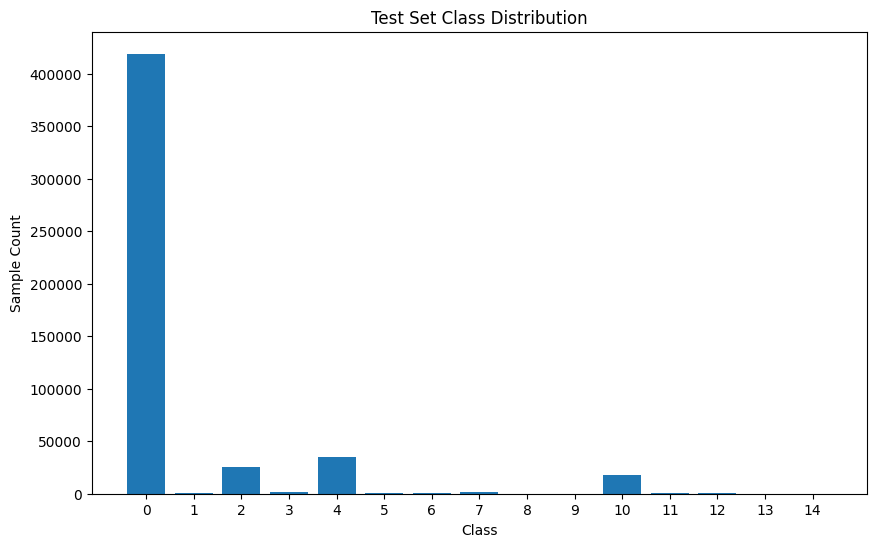

In [15]:
plt.figure(figsize=(10, 6))

plt.bar(
    distribution_df["Class"].astype(str),
    distribution_df["Count"]
)

plt.title("Test Set Class Distribution")

plt.xlabel("Class")

plt.ylabel("Sample Count")

plt.show()